# Image Recognition

In [1]:
# Import libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

# Set print options for PyTorch tensors
torch.set_printoptions(precision=2, linewidth=50000, profile="full", sci_mode=False)


class MLP(nn.Module):
    def __init__(self, n_hidden=100):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, n_hidden, bias=False),
            nn.BatchNorm1d(n_hidden),
            nn.Tanh(),
            nn.Linear(n_hidden, 10, bias=False),
        )

        # Initialization (similar to your manual logic)
        with torch.no_grad():
            for layer in self.net:
                if isinstance(layer, nn.Linear):
                    nn.init.kaiming_normal_(layer.weight, nonlinearity='tanh')
            self.net[-1].weight *= 0.01  # scale last layer

    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.net(x)
    

@torch.no_grad()
def evaluate(model, loader):
    """
    Evaluates a PyTorch model on a given DataLoader.

    Args:
        model (nn.Module): The model to evaluate.
        loader (DataLoader): DataLoader containing the dataset (e.g., validation or test).

    Returns:
        tuple (float, float): Average loss and accuracy (between 0 and 1).
    """
    model.eval()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for Xb, Yb in loader:
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb, reduction='sum')
        total_loss += loss.item()
        total_correct += (logits.argmax(dim=1) == Yb).sum().item()
        total_samples += Yb.size(0)
    
    return total_loss / total_samples, total_correct / total_samples

## Train, Test, and Validation Splits

When working with neural networks, it is common practice to divide the dataset into three splits:

- The **train split** (80% of the dataset) is used to optimize the model parameters during training.
- The **validation split** (10% of the dataset) is used to help us adjust the hyperparameters of the model.
- The **test split** (10% of the dataset) is used to evaluate the final model's performance.

<br>

| **Metric** | **Typical Use** | **Notes** |
|-|-|-|
| Train Loss | Monitor how well the model is learning | Should decrease over epochs. If it doesn't, possible issues include a too low/high learning rate, underfitting (model too simple), or noisy data. |
| Val Loss | Monitor how well the model generalizes | Should also decrease. If Train Loss ↓ but Val Loss ↑, it indicates overfitting (model too complex or too much training). Commonly used in early stopping. |
| Val Accuracy  | Measures model performance on unseen data | Often more interpretable than loss, especially for classification tasks. |
| Test Loss/Accuracy | Report final model performance | Use only after the model is fully optimized. Using the test split to help us adjust the hyperparameters of the model would result in overfitting. |

In [2]:
# Load the dataset
train_ds = MNIST(root="../data", train=True,  download=True, transform=ToTensor())
test_ds  = MNIST(root="../data", train=False, download=True, transform=ToTensor())

# Split full training set into train and validation
g = torch.Generator().manual_seed(1)
train_ds, val_ds = random_split(train_ds, [50000, 10000], generator=g)

# DataLoaders
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=batch_size)
test_loader  = DataLoader(test_ds,  batch_size=batch_size)

In [9]:
def print_log(log):
    """
    Print formatted training log table.
    
    Parameters:
        log (str): Formatted log string with one line per epoch.
    """
    print(f"| {'Epoch':^5} | {'Train Loss':^10} | {'Val Loss':^8} | {'Val Accuracy':^12} |")
    print(f"|{'-'*7}|{'-'*12}|{'-'*10}|{'-'*14}|")
    print(log)

In [4]:
def plot_metrics(metrics):
    """
    Plot training and validation loss, and validation accuracy over epochs.

    Parameters:
        metrics (list): List of tuples of the form (train_loss, val_loss, val_accuracy).
    """
    train_losses, val_losses, val_accuracies = zip(*metrics)
    epochs_range = range(1, len(metrics) + 1)
    
    plt.figure(figsize=(12, 4))

    # Plot Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, train_losses, label="Train Loss", marker='o')
    plt.plot(epochs_range, val_losses, label="Val Loss", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.xticks(epochs_range)
    plt.legend()
    plt.title("Loss")

    # Plot Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, [acc * 100 for acc in val_accuracies], label="Val Accuracy", marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.xticks(epochs_range)
    plt.legend()
    plt.title("Accuracy")

    plt.tight_layout()
    plt.show()

In [ ]:
# Hyperparameters
epochs = 9          # Number of times the dataset is fully seen
batch_size = 32     # Number of examples per batch
lr = 0.1            # Learning rate


# Initialize model
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
log = ""
metrics = []


# Train model
for epoch in range(epochs):
    model.train()
    running_train_loss = 0

    for Xb, Yb in train_loader:
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_loss = running_train_loss / len(train_loader)
    val_loss, val_accuracy = evaluate(model, val_loader)
    
    metrics.append((train_loss, val_loss, val_accuracy))
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} | {val_loss:^8.4f} | {f'{val_accuracy*100:.2f}%':^12} |\n"


# Evaluate model
test_loss, test_accuracy = evaluate(model, test_loader)
log += f"\nTest Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy*100:.2f}%"

print_log(log)

| Epoch | Train Loss | Val Loss | Val Accuracy |
|-------|------------|----------|--------------|
|   1   |   0.3374   |  0.1697  |    95.12%    |
|   2   |   0.1747   |  0.1335  |    95.94%    |
|   3   |   0.1305   |  0.1239  |    96.34%    |
|   4   |   0.1063   |  0.1062  |    96.72%    |
|   5   |   0.0909   |  0.0949  |    97.17%    |
|   6   |   0.0789   |  0.1041  |    96.68%    |
|   7   |   0.0667   |  0.0969  |    97.19%    |
|   8   |   0.0614   |  0.0889  |    97.25%    |
|   9   |   0.0570   |  0.0843  |    97.45%    |

Test Loss: 0.0786    Test Accuracy: 97.46%


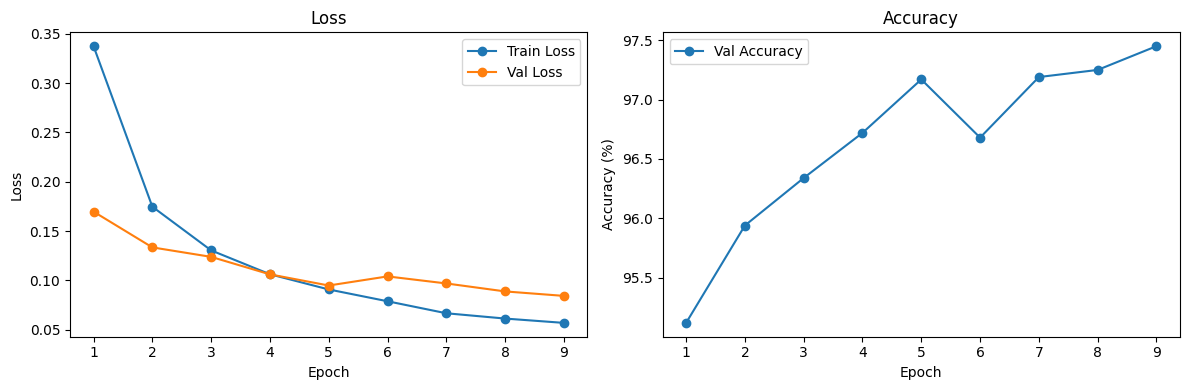

In [11]:
plot_metrics(metrics)

## Underfitting and Overfitting

Underfitting happens when a model is too simple or not trained enough to capture the underlying patterns in the data. It performs poorly both on training data and on validation/test data.

Overfitting happens when a model learns the training data too well, including the noise or random fluctuations, instead of general patterns. It performs great on training data but poorly on new unseen data (validation/test data). 

This typically occurs when:

- The model is too complex: For example, too many layers or too many parameters.

- Training for too long: If you train a complex model for too many epochs, it starts fitting not just the true signal but also noise in the training set.

## Early Stopping

In [15]:
class EarlyStopping:
    def __init__(self, patience=3):
        self.patience = patience
        self.best_val_loss = float('inf')
        self.epochs_no_improve = 0
        self.best_model_state = None
        self.stop = False
    
    def __call__(self, val_loss, epoch, model, log):
        if val_loss < self.best_val_loss:
            self.best_val_loss = val_loss
            self.epochs_no_improve = 0
            self.best_model_state = model.state_dict()
        else:
            self.epochs_no_improve += 1
            if self.epochs_no_improve >= self.patience:
                self.stop = True
                log += f"\nEarly stopping triggered at epoch {epoch+1}\n"
                log += f"Best epoch was {epoch+1 - self.patience}, loaded those weights\n"
        return log

In [ ]:
# Hyperparameters
max_epochs = 100
patience = 3
batch_size = 32     # Number of examples per batch
lr = 0.1            # Learning rate


# Intialize model
model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
early_stopper = EarlyStopping(patience=patience)
log = ""
metrics = []


# Train model
for epoch in range(max_epochs):
    model.train()
    running_train_loss = 0

    for Xb, Yb in train_loader:
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_loss = running_train_loss / len(train_loader)
    val_loss, val_accuracy = evaluate(model, val_loader)
    
    metrics.append((train_loss, val_loss, val_accuracy))
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} | {val_loss:^8.4f} | {f'{val_accuracy*100:.2f}%':^12} |\n"

    # Early stopping
    log = early_stopper(val_loss, epoch, model, log)
    if early_stopper.stop:
        break

# Load best model weights before testing
model.load_state_dict(early_stopper.best_model_state)

# Evaluate model
test_loss, test_accuracy = evaluate(model, test_loader)
log += f"\nTest Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy*100:.2f}%"

print_log(log)

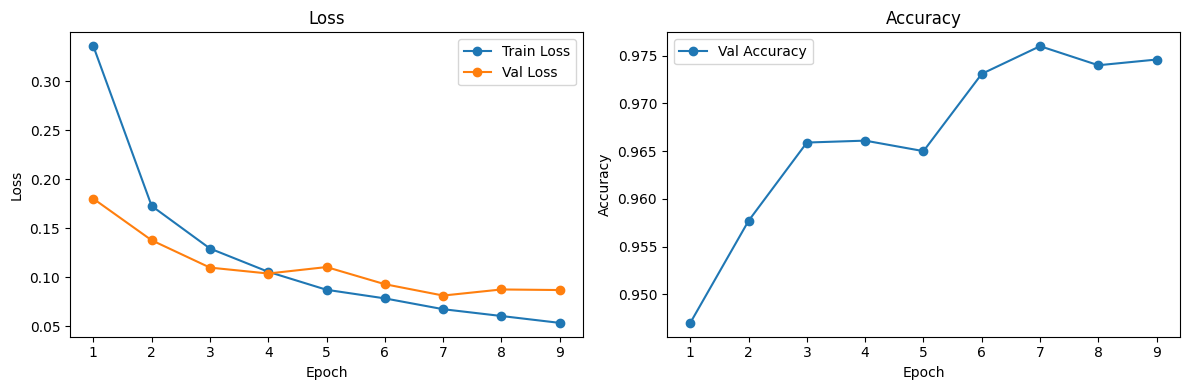

In [21]:
plot_metrics(metrics)

## Convolutional Neural Networks

In [22]:
class CNNModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # Input: (B, 1, 28, 28)
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> (B, 32, 14, 14)

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),                             # -> (B, 64, 7, 7)
        )

        self.classifier = nn.Sequential(
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(64, 10)  # Output layer
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten before Linear
        x = self.classifier(x)
        return x

In [31]:
# Hyperparameters
max_epochs = 100
patience = 3
batch_size = 32     # Number of examples per batch
lr = 0.1            # Learning rate


# Intialize model
model = CNNModel()
optimizer = torch.optim.SGD(model.parameters(), lr=lr)
early_stopper = EarlyStopping(patience=patience)
log = ""
metrics = []


# Train model
for epoch in range(max_epochs):
    model.train()
    running_train_loss = 0

    for Xb, Yb in train_loader:
        logits = model(Xb)
        loss = F.cross_entropy(logits, Yb)
        running_train_loss += loss.item()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    train_loss = running_train_loss / len(train_loader)
    val_loss, val_accuracy = evaluate(model, val_loader)
    
    metrics.append((train_loss, val_loss, val_accuracy))
    log += f"| {epoch+1:^5} | {train_loss:^10.4f} | {val_loss:^9.4f} | {val_accuracy:^12.4f} |\n"

    # Early stopping
    log = early_stopper(val_loss, epoch, model, log)
    if early_stopper.stop:
        break

# Load best model weights before testing
model.load_state_dict(early_stopper.best_model_state)

# Evaluate model
test_loss, test_accuracy = evaluate(model, test_loader)
log += f"Test Loss: {test_loss:.4f}    Test Accuracy: {test_accuracy:.4f}"

print_log(log)

| Epoch | Train Loss | Val Loss  | Val Accuracy |
|-------|------------|-----------|--------------|
|   1   |   0.5332   |  0.0873   |    0.9725    |
|   2   |   0.1578   |  0.0611   |    0.9819    |
|   3   |   0.1166   |  0.0570   |    0.9839    |
|   4   |   0.0935   |  0.0432   |    0.9867    |
|   5   |   0.0816   |  0.0476   |    0.9866    |
|   6   |   0.0719   |  0.0426   |    0.9879    |
|   7   |   0.0656   |  0.0440   |    0.9866    |
|   8   |   0.0556   |  0.0421   |    0.9881    |
|   9   |   0.0541   |  0.0384   |    0.9891    |
|  10   |   0.0515   |  0.0378   |    0.9897    |
|  11   |   0.0435   |  0.0406   |    0.9886    |
|  12   |   0.0438   |  0.0415   |    0.9883    |
|  13   |   0.0398   |  0.0382   |    0.9901    |

Early stopping triggered at epoch 13
Best epoch was 10
Test Loss: 0.0304    Test Accuracy: 0.9916


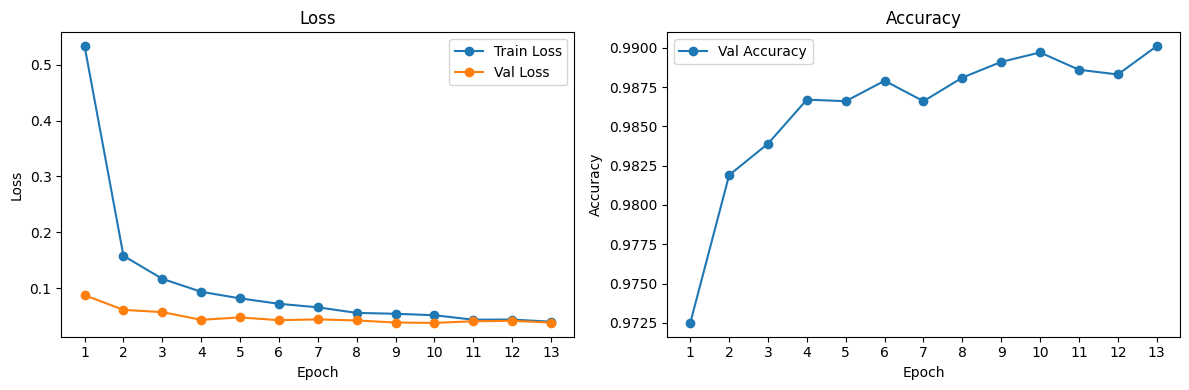

In [32]:
plot_metrics(metrics)

## Confusion Matrix

In [24]:
logits.shape

torch.Size([16, 10])

In [25]:
logits

tensor([[  2.95, -11.58,   1.40,  -9.62,  18.25,  -0.17,   3.31,  -1.41,  -1.64,   4.20],
        [ -4.66,   8.27,  -0.32,   0.25,  -3.33,  -0.25,  -2.51,   5.96,  -2.00,  -0.73],
        [  1.54,  -3.54,   9.20,  -3.38,  -1.60,  -5.84,   0.68,  -1.70,   3.43,   0.24],
        [ -4.45,   6.22,  16.84,  -3.75,   1.15,  -4.12,   6.67,  -1.96,  -1.84,  -9.98],
        [ -2.11,   1.64,   0.77,   0.57,   0.07,  -4.92,  -5.34,   9.87,  -0.56,   6.20],
        [ 14.85, -11.22,  -1.24,  -4.61,  -1.93,  -2.09,  -5.99,   7.85,  -1.72,   3.29],
        [ -9.49,  -2.63,   9.67,  26.40, -12.84,   0.34, -14.84,  10.71,   8.32,  -1.18],
        [  0.21,  -8.64,   1.46,   6.52,  -5.78,  -0.68,  -5.15,  -7.37,  18.66,   1.52],
        [-12.67,  -4.56,   9.93,  31.34, -10.69,   4.61, -20.62,   4.31,   5.22,  -1.34],
        [  0.39,   2.87,  20.02,   0.59,  -0.73,  -8.27,  -5.10,   2.06,   1.59, -11.92],
        [-12.17,  -5.41, -13.59,  14.39,  -9.91,  21.93,   1.89,  -8.04,   1.84,  12.16],
        [ 

In [26]:
pred = torch.argmax(logits, dim=1)
pred

tensor([4, 1, 2, 2, 7, 0, 3, 8, 3, 2, 5, 0, 3, 8, 9, 7])

In [27]:
Yb

tensor([4, 1, 2, 2, 7, 0, 3, 8, 3, 2, 5, 0, 3, 8, 9, 7])

In [28]:
conf_matrix = torch.zeros(10, 10, dtype=torch.int32)

for t, p in zip(Yb, pred):
    conf_matrix[t, p] += 1

conf_matrix

tensor([[2, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 3, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 3, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 2, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 0, 1]], dtype=torch.int32)